# Geometric Grid Stretching #

Conside the subdivision of the interval $x \in [a,b]$ such that successive intervals sizes are related by a multiplier:

$$\Delta x_{i+1} = \alpha\Delta x_i$$

where $\Delta x_i=x_{i+1}-x_i$ is the difference between two successive nodes $s_i$ and $s_{i+1}$. To simplify the process, transform coordinates with $s = \frac{x-a}{b-a}$. The interval of interest is then $s\in[0,1]$ and

$$\Delta s_{i+1} = \alpha\Delta s_i.$$

Specifying the number of intervals as $N$, then

$$s_0 = 0$$
$$s_1 = 0 + \Delta s_0$$
$$s_2 = 0 + \Delta s_0 + \alpha\Delta s_0$$
$$s_n = \sum_{k=0}^n \alpha^{k} \Delta s_0 - \Delta s_0$$
$$s_N = \sum_{k=0}^N \alpha^{k} \Delta s_0 - \Delta s_0 = 1$$

The name "geometric" arises because of the presence of the finite geometric series in the formula, which can be used to calculate the nodal values for any $i$, most notably the endpoint (as long as $\alpha\ne 1$):

$$\sum_{k=0}^N \alpha^k \Delta s_0 = \frac{1-\alpha^{N+1}}{1-\alpha}\Delta s_0, \text{  for }\alpha \ne 1$$

Given an $N$ and $\Delta s_0$, this can be rewritten as a function to be used to solve for $\alpha$:

$$f(\alpha) = 1 - s_N = 1 + \Delta s_0 - \sum_{k=0}^N \alpha^{k} \Delta s_0 $$
$$f'(\alpha) = - \sum_{k=0}^{N-1} k\alpha^{k-1} \Delta s_0 $$


In [7]:
import math
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [14]:
def geometric_sum(a:float, r:float, i:int) -> float:
    return a * (1.0 - a**(i+1)) / (1.0-r)
def f(alpha:float, delta:float=0.1, N:int=10) -> float:
    return 1.0 + delta + geometric_sum(delta, alpha, N)

(1.0, 1.000000000001, 1.0000001)

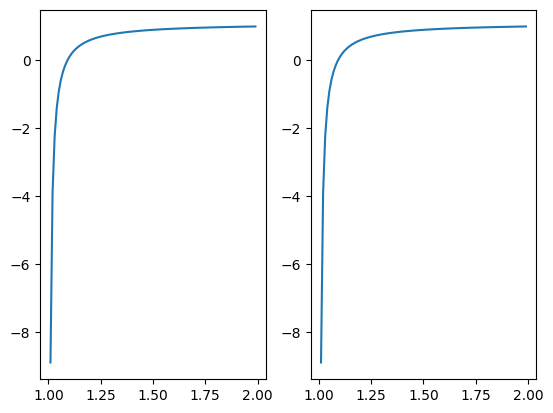

In [22]:
x = np.arange(1.01, 2.0, 0.01)
y = np.arange(1.01, 2.0, 0.01)
for i in range(len(x)):
    y[i] = f(x[i])
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=False)
ax1.plot(x, y)

for i in range(len(x)):
    y[i] = f(x[i], N=5)
ax2.plot(x, y)

(f(2, N=15), f(2, N=10), f(2, N=5))

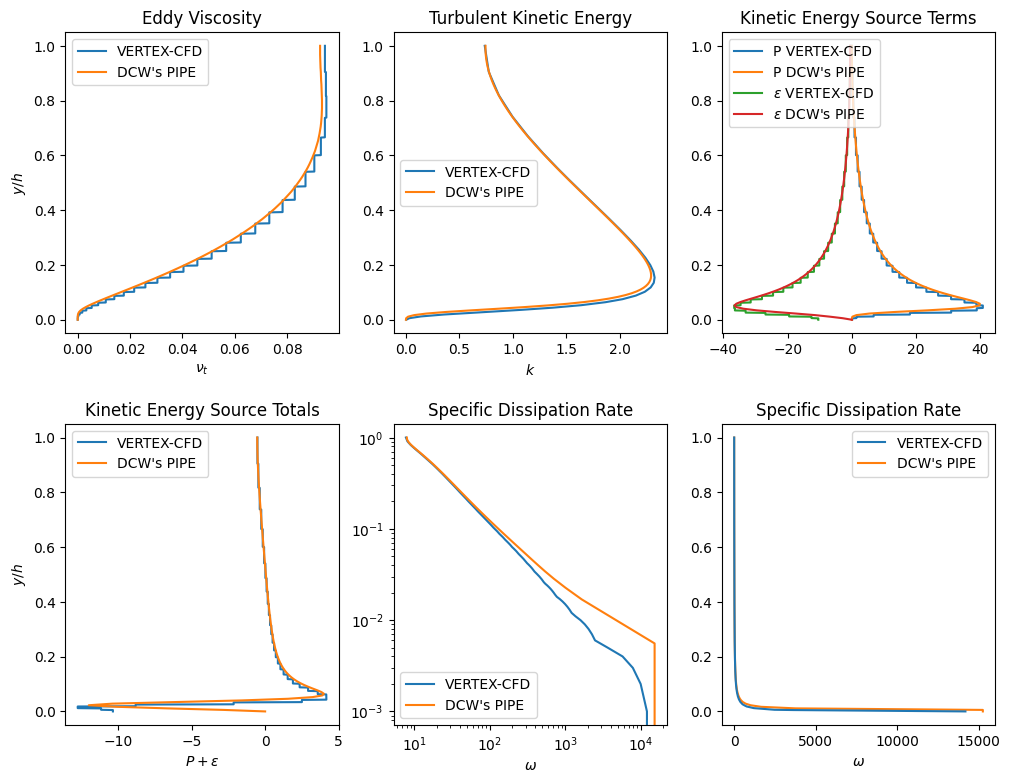

In [9]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, sharey=False)
fig.set_size_inches(12,9)
fig.subplots_adjust(hspace=0.3)
ax1.plot(kk_x0['turbulent_eddy_viscosity'], kk_x0['arc_length'], label='VERTEX-CFD')
ax1.plot(dcw_kw['nu_t']/180.0, dcw_kw['y/h'], label="DCW's PIPE")
ax1.set_xlabel('$\\nu_t$')
ax1.set_ylabel('$y/h$')
ax1.legend(loc='upper left')
ax1.set_title('Eddy Viscosity')

ax2.plot(kk_x0['turb_kinetic_energy'], kk_x0['arc_length'], label='VERTEX-CFD')
ax2.plot(dcw_kw['k+'], dcw_kw['y/h'], label="DCW's PIPE")
ax2.set_xlabel('$k$')
ax2.legend(loc='center left')
ax2.set_title('Turbulent Kinetic Energy')

ax3.plot(kk_x0['PRODUCTION_turb_kinetic_energy_equation'], kk_x0['arc_length'], label='P VERTEX-CFD')
ax3.plot(180.0*dcw_kw['P+'], dcw_kw['y/h'], label="P DCW's PIPE")
ax3.plot(kk_x0['DESTRUCTION_turb_kinetic_energy_equation'], kk_x0['arc_length'], label='$\\epsilon$ VERTEX-CFD')
ax3.plot(180.0*dcw_kw['e+'], dcw_kw['y/h'], label="$\\epsilon$ DCW's PIPE")
ax3.legend(loc='upper left')
ax3.set_title('Kinetic Energy Source Terms')

ax4.plot(kk_x0['SOURCE_turb_kinetic_energy_equation'], kk_x0['arc_length'], label='VERTEX-CFD')
ax4.plot(180.0*(dcw_kw['P+'] + dcw_kw['e+']), dcw_kw['y/h'], label="DCW's PIPE")
#ax3.plot(kk_x0['DESTRUCTION_turb_kinetic_energy_equation'], kk_x0['arc_length'], label='$\\epsilon$ VERTEX-CFD')
#ax3.plot(180.0*dcw_kw['e+'], dcw_kw['y/h'], label="$\\epsilon$ DCW's PIPE")
ax4.legend(loc='upper left')
ax4.set_title('Kinetic Energy Source Totals')
ax4.set_ylabel('$y/h$')
ax4.set_xlabel('$P + \\epsilon$')

ax5.plot(kk_x0['turb_specific_dissipation_rate'], kk_x0['arc_length'], label='VERTEX-CFD')
#ax1.plot(180*kk_x0['arc_length'], kk_x0['velocity_0'], label='VERTEX-CFD')
ax5.plot(180*dcw_kw['omega+'], dcw_kw['y/h'], label="DCW's PIPE")
#ax1.plot(dcw_kw['y+'], dcw_kw['y+'], label='Viscous sublayer')
#ax.plot(dcw_kw['y+'][1:], np.log(dcw_kw['y+'][1:])/0.41 + 5.2, label='Log law')
ax5.set_xscale('log')
ax5.set_yscale('log')
#ax.set_ylim([0, 20])
#ax.grid(visible=True)
ax5.legend(loc='lower left')
ax5.set_title('Specific Dissipation Rate')
ax5.set_xlabel('$\\omega$')

ax6.plot(kk_x0['turb_specific_dissipation_rate'], kk_x0['arc_length'], label='VERTEX-CFD', zorder=10)
#ax1.plot(180*kk_x0['arc_length'], kk_x0['velocity_0'], label='VERTEX-CFD')
ax6.plot(180*dcw_kw['omega+'], dcw_kw['y/h'], label="DCW's PIPE", zorder=0)
#ax1.plot(dcw_kw['y+'], dcw_kw['y+'], label='Viscous sublayer')
#ax.plot(dcw_kw['y+'][1:], np.log(dcw_kw['y+'][1:])/0.41 + 5.2, label='Log law')
#ax6.set_xscale('log')
#ax6.set_yscale('log')
#ax.set_ylim([0, 20])
#ax.grid(visible=True)
ax6.legend(loc='upper right')
ax6.set_title('Specific Dissipation Rate')
ax6.set_xlabel('$\\omega$')
None

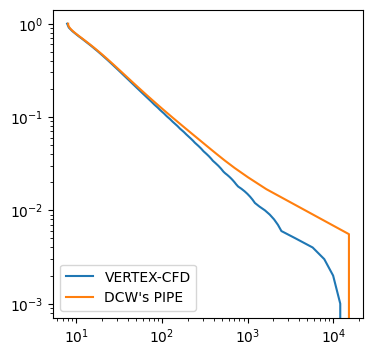

In [12]:
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(4, 4)
ax1.plot(kk_x0['turb_specific_dissipation_rate'], kk_x0['arc_length'], label='VERTEX-CFD')
#ax1.plot(180*kk_x0['arc_length'], kk_x0['velocity_0'], label='VERTEX-CFD')
ax1.plot(180*dcw_kw['omega+'], dcw_kw['y/h'], label="DCW's PIPE")
#ax1.plot(dcw_kw['y+'], dcw_kw['y+'], label='Viscous sublayer')
#ax.plot(dcw_kw['y+'][1:], np.log(dcw_kw['y+'][1:])/0.41 + 5.2, label='Log law')
ax1.set_xscale('log')
ax1.set_yscale('log')
#ax.set_ylim([0, 20])
#ax.grid(visible=True)
ax1.legend(loc='lower left')
#ax.set_title('Log Law Profiles')

Text(0.5, 1.0, 'Eddy Viscosity')

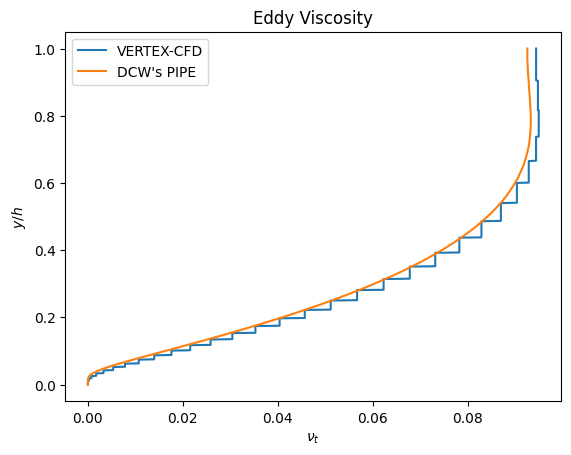

In [13]:
fig, (ax1) = plt.subplots(1, 1, sharey=False)
ax1.plot(kk_x0['turbulent_eddy_viscosity'], kk_x0['arc_length'], label='VERTEX-CFD')
ax1.plot(dcw_kw['nu_t']/180.0, dcw_kw['y/h'], label="DCW's PIPE")
ax1.set_xlabel('$\\nu_t$')
ax1.set_ylabel('$y/h$')
ax1.legend(loc='upper left')
ax1.set_title('Eddy Viscosity')

Text(0.5, 1.0, 'Log Law Profiles')

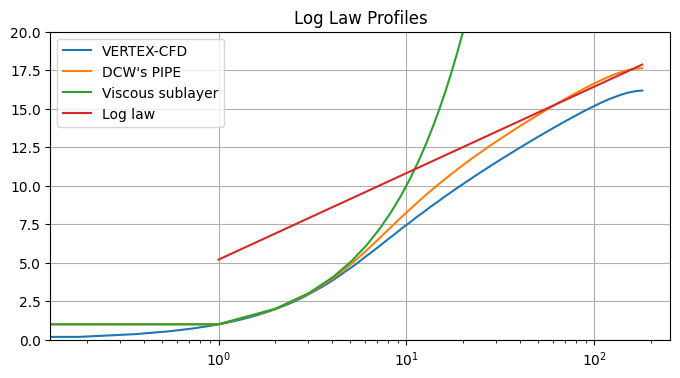

In [11]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 4)
ax.plot(180*kk_x0['arc_length'], kk_x0['velocity_0'], label='VERTEX-CFD')
ax.plot(dcw_kw['y+'], dcw_kw['u+'], label="DCW's PIPE")
ax.plot(dcw_kw['y+'], dcw_kw['y+'], label='Viscous sublayer')
ax.plot(dcw_kw['y+'][1:], np.log(dcw_kw['y+'][1:])/0.41 + 5.2, label='Log law')
ax.set_xscale('log')
ax.set_ylim([0, 20])
ax.grid(visible=True)
ax.legend(loc='upper left')
ax.set_title('Log Law Profiles')

In [8]:
kk_x0.columns

Index(['Point ID', 'arc_length',
       'CROSS_DIFFUSION_turb_specific_dissipation_rate_equation',
       'DESTRUCTION_turb_kinetic_energy_equation',
       'DESTRUCTION_turb_specific_dissipation_rate_equation',
       'diffusivity_turb_kinetic_energy',
       'diffusivity_turb_specific_dissipation_rate', 'GRAD_velocity_0X',
       'GRAD_velocity_0Y', 'GRAD_velocity_1X', 'GRAD_velocity_1Y', 'ids',
       'lagrange_pressure', 'LOAD_BAL', 'object_id', 'Points_0', 'Points_1',
       'Points_2', 'Points_Magnitude', 'PROC_ID',
       'PRODUCTION_turb_kinetic_energy_equation',
       'PRODUCTION_turb_specific_dissipation_rate_equation',
       'SOURCE_turb_kinetic_energy_equation',
       'SOURCE_turb_specific_dissipation_rate_equation', 'turb_kinetic_energy',
       'turb_specific_dissipation_rate', 'turbulent_eddy_viscosity',
       'velocity_0', 'velocity_1', 'vtkValidPointMask'],
      dtype='object')

In [31]:
dcw_kw.columns

Index(['Unnamed: 0', 'y/h', 'u/U', 'y+', 'u+', '-u'v'', 'k+', 'e+', 'P+',
       'nu_t', 'omega+'],
      dtype='object')

In [7]:
kk_x0['turbulent_eddy_viscosity']


0       0.000005
1       0.000005
2       0.000005
3       0.000005
4       0.000005
          ...   
996     0.094441
997     0.094441
998     0.094441
999     0.094441
1000    0.094441
Name: turbulent_eddy_viscosity, Length: 1001, dtype: float64

In [33]:
kk_x0['turb_specific_dissipation_rate'][:40]

0     9495.611789
1     8221.728680
2     6947.845571
3     5673.962611
4     4400.079353
5     3126.196689
6     2388.120219
7     2177.797328
8     1967.474437
9     1757.151742
10    1546.828851
11    1336.505960
12    1189.970130
13    1118.935313
14    1047.900497
15     976.865746
16     905.830864
17     834.796047
18     763.761363
19     725.226057
20     694.436773
21     663.647488
22     632.858204
23     602.068920
24     571.279635
25     540.490351
26     516.877410
27     500.672078
28     484.466746
29     468.261444
30     452.056112
31     435.850780
32     419.645417
33     403.440116
34     390.076946
35     380.257639
36     370.438332
37     360.618989
38     350.799682
39     340.980339
Name: turb_specific_dissipation_rate, dtype: float64

In [69]:
dcw_kw['omega+'][:10]*180

0    1525500.0
1    1525500.0
2     374760.0
3     163656.0
4      90450.0
5      56880.0
6      38808.0
7      28008.0
8      21060.0
9      16347.6
Name: omega+, dtype: float64

In [36]:
kk_x0['arc_length'][:10]

0    0.000
1    0.001
2    0.002
3    0.003
4    0.004
5    0.005
6    0.006
7    0.007
8    0.008
9    0.009
Name: arc_length, dtype: float64